In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
from scipy.signal import argrelextrema
from scipy.stats import ttest_ind, ttest_1samp, fisher_exact
import statsmodels.api as sm

In [2]:
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['axes.labelsize'] = 'small'
matplotlib.rcParams['axes.linewidth'] = 1
matplotlib.rcParams['lines.markersize'] = 2
matplotlib.rcParams['xtick.major.width'] = 1
matplotlib.rcParams['ytick.major.width'] = 1
matplotlib.rcParams['xtick.labelsize'] = 'x-small'
matplotlib.rcParams['ytick.labelsize'] = 'x-small'
matplotlib.rcParams['legend.fontsize'] = 'x-small'
matplotlib.rcParams['figure.dpi'] = 600

# 1. Load human birth-dating data

In [3]:
birthdating_df = pd.read_excel('./Dataset_S1.xlsx', sheet_name='Data')
pd.options.display.float_format = '{:.4f}'.format
display(birthdating_df)
pd.reset_option('display.float_format')

,Uniprot,KGG peptides detected,KGG peptides number,KGG peptides,KGG peptides log2 ratio +- MG132,Maximum KGG peptides log2 ratio +- MG132,Median KGG peptides log2 ratio +- MG132,Ages of KGG peptides,Minimum age of KGG peptides,Median age of KGG peptides,Ages of unmodified peptides,Number of unmodified peptides,Median ages of unmodified peptides,Log2 ratio of youngest KGG peptide vs. median of unmodified peptides
0,P60709,True,22.0000,"{""DLTDYLMKILTER"", ""DLTDYLMKILTER"", ""DSYVGDEAQS...","{1.0067258631883134, 2.4574430655438437, 3.823...",12.6618,2.8749,"{9.199200234, 9.199200234, 0.142014102, 0.1459...",0.0792,0.1223,"{6.846411538, 0.063056182}",2.0000,3.4547,-5.4471
1,P78417,True,8.0000,"{""ACQKMILELFSK"", ""LEAMKLNECVDHTPK"", ""LEAMKLNEC...","{5.832890014164742, 6.971232701815302, 6.12928...",11.2408,6.5503,"{0.155160372, 0.150730573, 0.150730573, ""NA"", ...",0.1507,0.1727,"{4.532277066, 0.624726375, 5.17429808, 4.28860...",8.0000,4.0292,-4.7405
2,P14618,True,37.0000,"{""AEGSDVANAVLDGADCIMLSGETAKGDYPLEAVR"", ""AEGSDV...","{4.183897943994917, 5.303715112612994, 1.86736...",11.1293,4.6262,"{""NA"", ""NA"", 0.10782916, 0.078821733, 0.084596...",0.0611,0.0820,"{4.858434357, 5.043380866, 4.37522975, 4.68376...",28.0000,4.5417,-6.2160
3,P52272,True,10.0000,"{""ADILEDKDGKSR"", ""ADILEDKDGK"", ""FEPYANPTKR"", ""...","{3.8886283892157905, 5.568831123937785, 7.4396...",11.1033,5.4848,"{""NA"", 2.659722011, 0.81632155, ""NA"", 3.158040...",0.8163,3.0984,"{5.303402701, 3.647272762, 3.603764562, 2.8481...",15.0000,3.5789,-2.1323
4,P0DMV8,True,32.0000,"{""AFYPEEISSMVLTKMK"", ""AMTKDNNLLGR"", ""AMTKDNNLL...","{8.63662462054365, 4.6067170533616775, 3.78613...",10.8361,6.0684,"{1.556611334, 0.061276321, 0.061276321, 0.0739...",0.0375,0.0717,"{0.671383158, 2.892423354, 3.406676147, 3.1947...",17.0000,2.8924,-6.2683
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6445,Q9Y6N1,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6446,Q9Y6R0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{1.146118286, 1.483630049, 1.004755659, 1.1086...",5.0000,1.1461,NaN
6447,Q9Y6R4,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{1.548861459, 0.241370669}",2.0000,0.8951,NaN
6448,Q9Y6W5,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{2.341540928, 2.788667299, 1.208367543, 3.1762...",5.0000,2.7887,NaN


# 2. Identify cutoff for ubiquitin-proteasome degradation

Ubiquitin-proteasome degradation cutoff = 2.7554


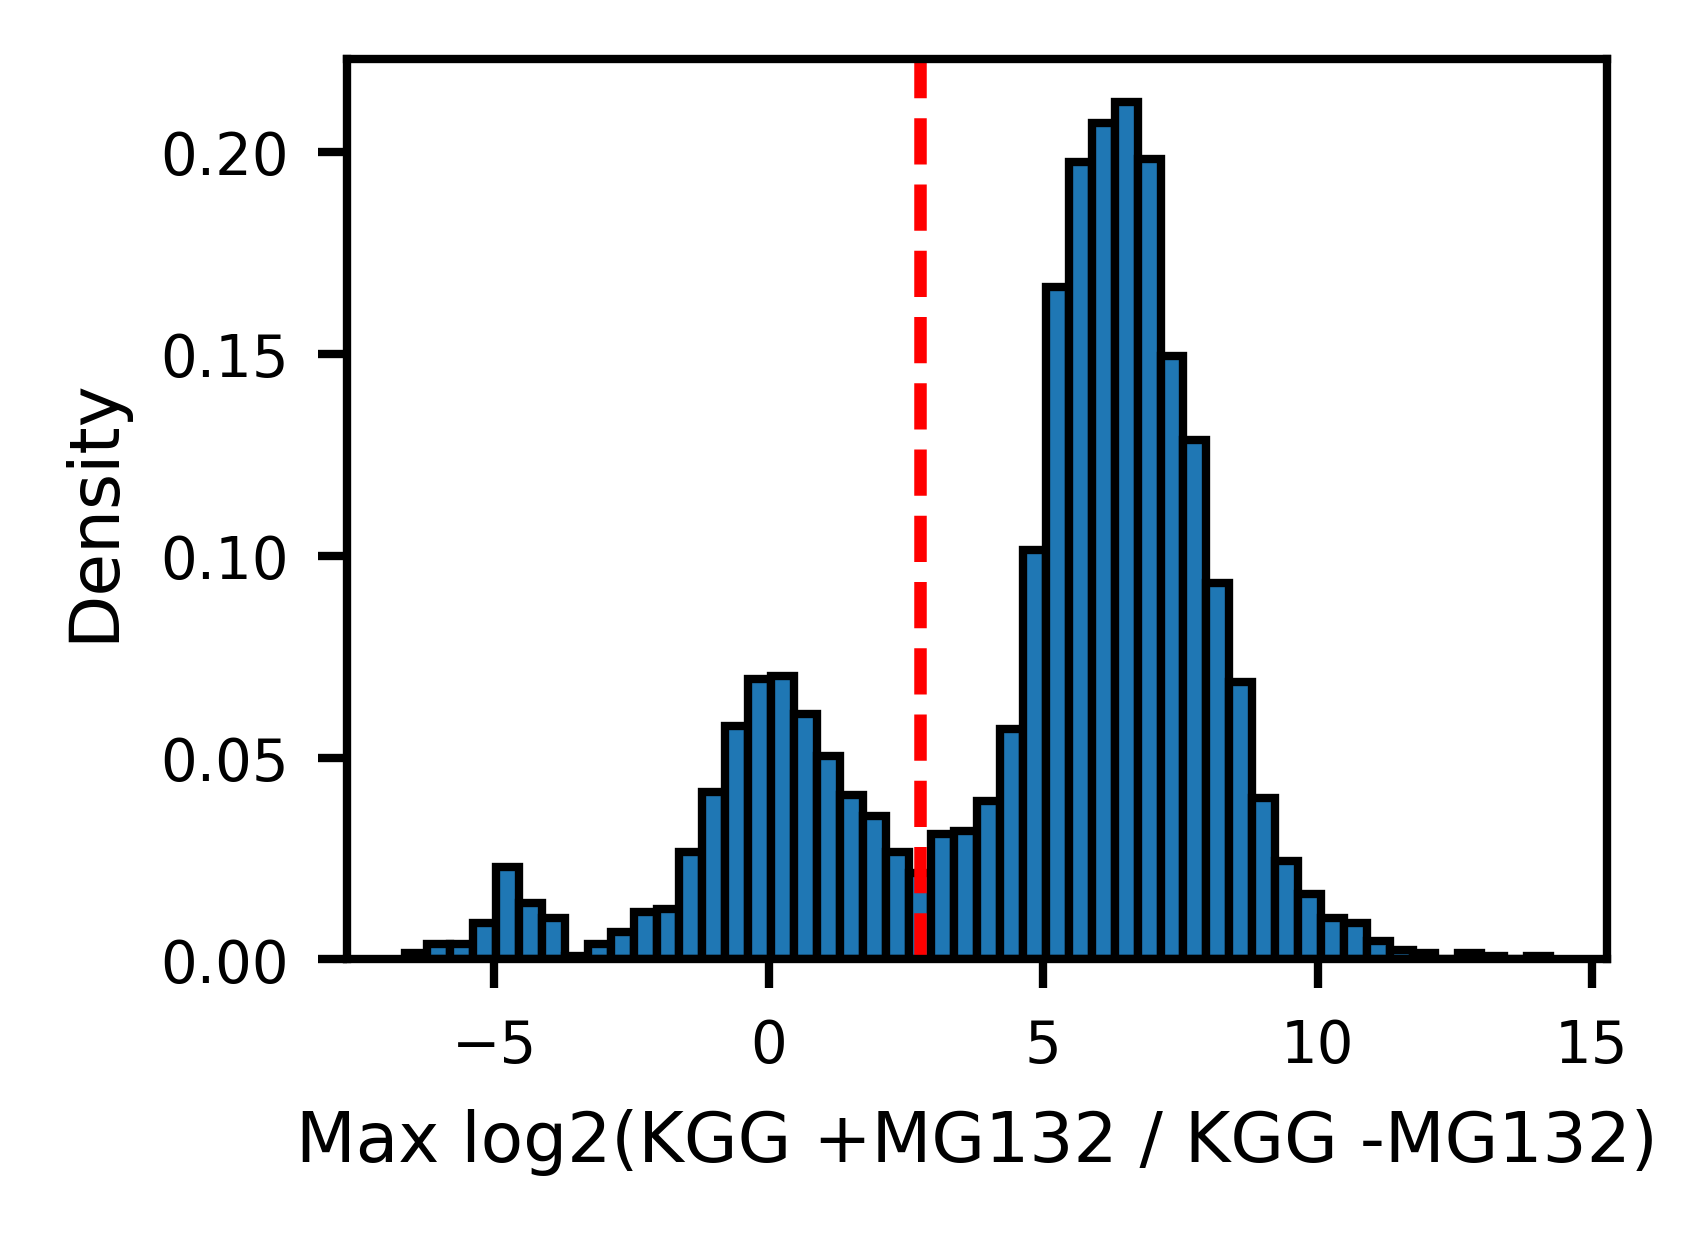

,Uniprot,KGG peptides detected?,KGG increase w MG132?
0,P60709,Y,Y
1,P78417,Y,Y
2,P14618,Y,Y
3,P52272,Y,Y
4,P0DMV8,Y,Y
...,...,...,...
6445,Q9Y6N1,N,NaN
6446,Q9Y6R0,N,NaN
6447,Q9Y6R4,N,NaN
6448,Q9Y6W5,N,NaN


In [4]:
data = birthdating_df['Maximum KGG peptides log2 ratio +- MG132'].to_numpy()
data = data[~np.isnan(data)]

nbins = 50

p, e = np.histogram(data, bins=nbins, density=True)
idx_list = argrelextrema(p, np.less)[0]
cutoff = (e[idx_list] + e[idx_list+1])/2
cutoff = np.min(cutoff[cutoff > 0])
print('Ubiquitin-proteasome degradation cutoff = %.4f'%cutoff)

# Plot distribution
fig = plt.figure(figsize=(3,2))
plt.subplots_adjust(top=0.95, bottom=0.20, left=0.20, hspace=0.30)
ax = fig.add_subplot(1,1,1)
ax.hist(data, bins=nbins, density=True, edgecolor='black')
ylim = ax.get_ylim()
ax.plot([cutoff, cutoff], ylim, '--r')
ax.set_ylim(ylim)
ax.set_xlabel('Max log2(KGG +MG132 / KGG -MG132)')
ax.set_ylabel('Density')
plt.show()

# Label proteins
birthdating_labelled_df = pd.DataFrame({
    'Uniprot': birthdating_df['Uniprot'],
    'KGG peptides detected?': birthdating_df['KGG peptides detected'].apply(lambda x: 'Y' if x else 'N'),
    'KGG increase w MG132?': birthdating_df['Maximum KGG peptides log2 ratio +- MG132'].apply(lambda x: 'Y' if pd.notna(x) and x > cutoff else ('N' if pd.notna(x) else np.nan))
})
display(birthdating_labelled_df)

# 3. Identify cutoff for young ubiquitinated proteins

Max Cutoff = -1.8510


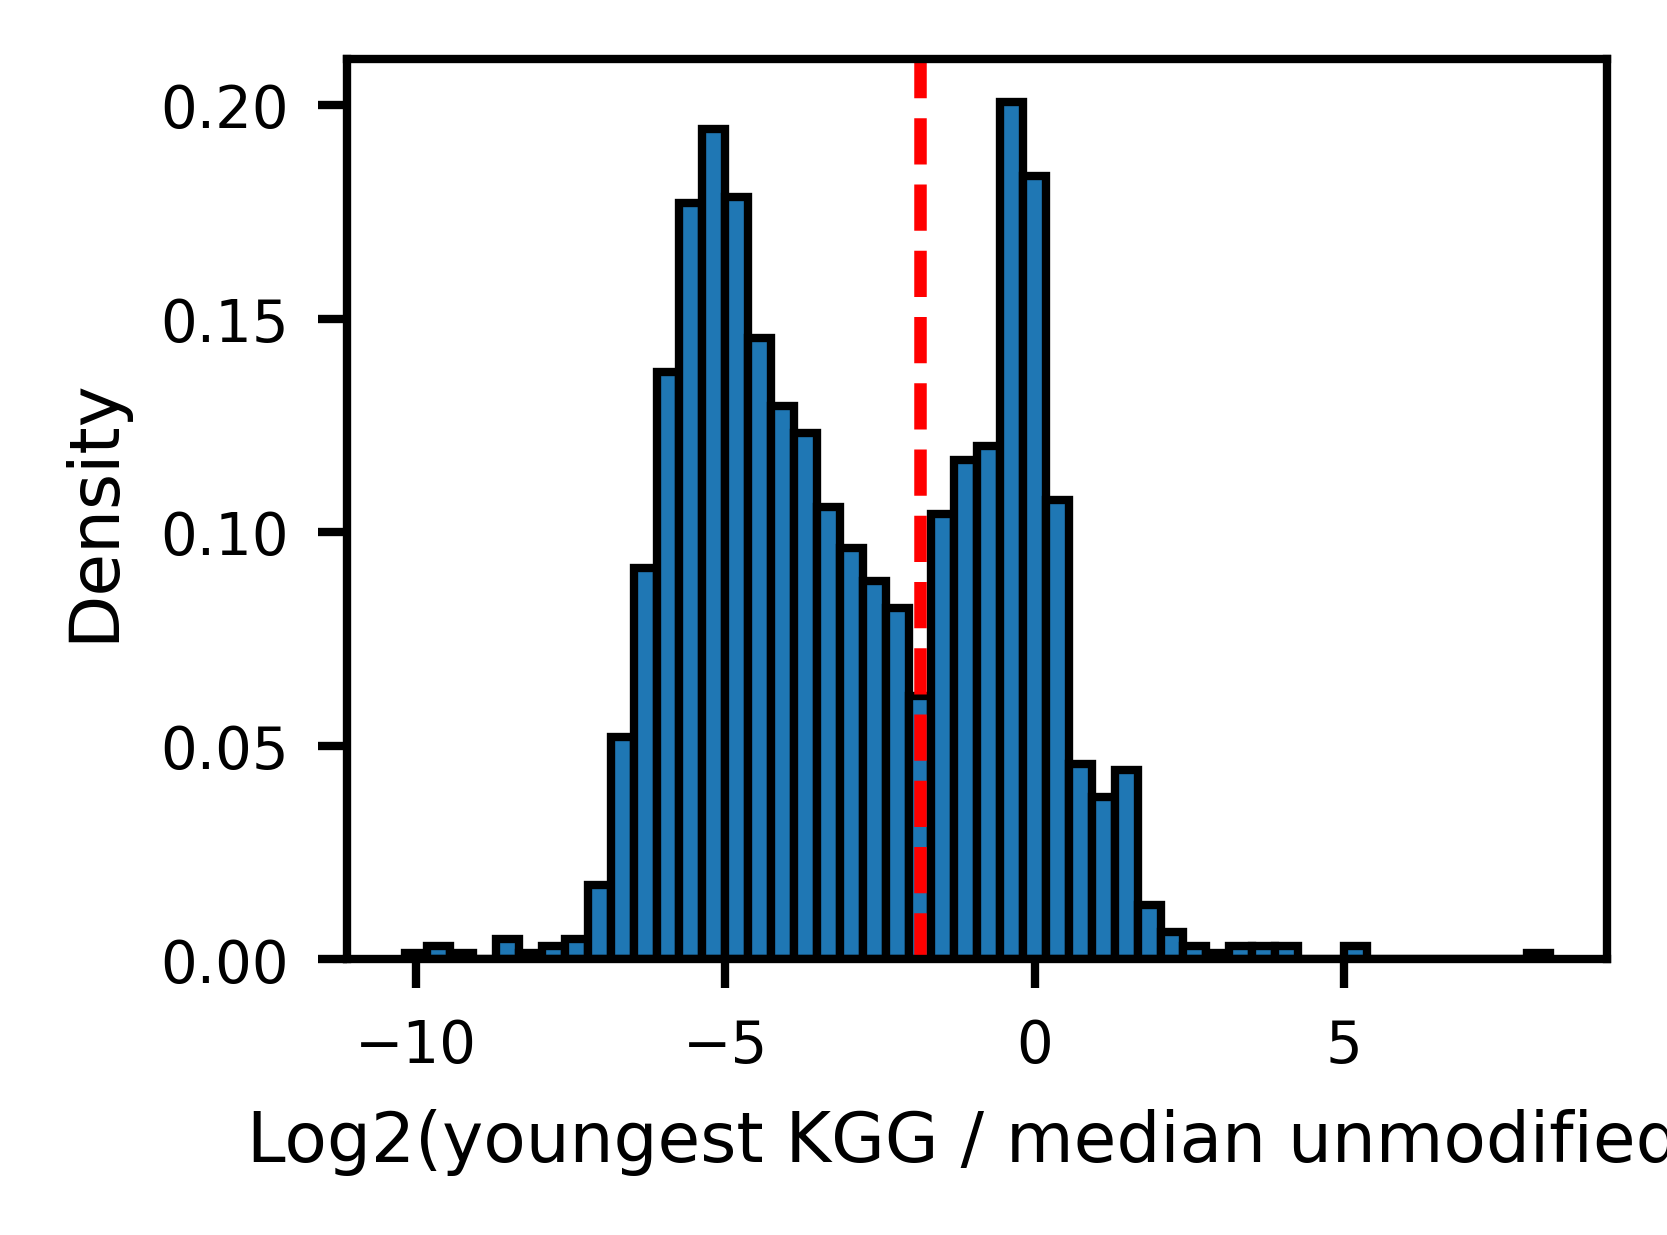

,Uniprot,KGG peptides detected?,KGG increase w MG132?,KGG young?
0,P60709,Y,Y,Y
1,P78417,Y,Y,Y
2,P14618,Y,Y,Y
3,P52272,Y,Y,Y
4,P0DMV8,Y,Y,Y
...,...,...,...,...
6445,Q9Y6N1,N,NaN,NaN
6446,Q9Y6R0,N,NaN,NaN
6447,Q9Y6R4,N,NaN,NaN
6448,Q9Y6W5,N,NaN,NaN


In [5]:
data = birthdating_df['Log2 ratio of youngest KGG peptide vs. median of unmodified peptides'].to_numpy()
data = data[~np.isnan(data)]

nbins = 50

p, e = np.histogram(data, bins=nbins, density=True)
idx_list = argrelextrema(p, np.less)[0]
cutoff = (e[idx_list] + e[idx_list+1])/2
cutoff = np.max(cutoff[cutoff < 0])
print('Max Cutoff = %.4f'%cutoff)

# Plot distribution
fig = plt.figure(figsize=(3,2))
plt.subplots_adjust(top=0.95, bottom=0.20, left=0.20, hspace=0.30)
ax = fig.add_subplot(1,1,1)
ax.hist(data, bins=nbins, density=True, edgecolor='black')
ylim = ax.get_ylim()
ax.plot([cutoff, cutoff], ylim, '--r')
ax.set_ylim(ylim)
ax.set_xlabel('Log2(youngest KGG / median unmodified)')
ax.set_ylabel('Density')
plt.show()

# Label proteins
birthdating_labelled_df['KGG young?'] = birthdating_df['Log2 ratio of youngest KGG peptide vs. median of unmodified peptides'].apply(lambda x: 'Y' if pd.notna(x) and x < cutoff else ('N' if pd.notna(x) else np.nan))
display(birthdating_labelled_df)

# 4. Label proteins with ubiquitination status

In [6]:
UBQ_prot_df = birthdating_labelled_df[['Uniprot', 'KGG peptides detected?']].copy()
UBQ_prot_df.rename(columns={'KGG peptides detected?':'UBQ'}, inplace=True)

# Criteria #1: 
# UPS - "KGG peptides detected?" = Y
#       & "KGG increase w MG132?" = Y
labels = []
for index, row in birthdating_labelled_df.iterrows():
    if row['KGG peptides detected?'] == 'Y' \
        and row['KGG increase w MG132?'] == 'Y':
        label = 'Y'
    else:
        label = 'N'
    labels.append(label)
UBQ_prot_df['UPS'] = labels

# Criteria #2: 
# YU_1d - "KGG peptides detected?" = Y
#         & "KGG increase w MG132?" = Y
#         & "KGG young?" = Y
#         & "Youngest KGG age < 1 day?" = Y;
labels = []
for index, row in birthdating_labelled_df.iterrows():
    if row['KGG peptides detected?'] == 'Y' \
        and row['KGG increase w MG132?'] == 'Y' \
        and row['KGG young?'] == 'Y' \
        and birthdating_df.iloc[index,:]['Minimum age of KGG peptides'] < 1:
        label = 'Y'
    else:
        label = 'N'
    labels.append(label)
UBQ_prot_df['YU_1d'] = labels

# Criteria #3: 
# YU_1d - "KGG peptides detected?" = Y
#         & "KGG increase w MG132?" = Y
#         & "KGG young?" = Y
#         & "Youngest KGG age < 6 hours?" = Y;
labels = []
for index, row in birthdating_labelled_df.iterrows():
    if row['KGG peptides detected?'] == 'Y' \
        and row['KGG increase w MG132?'] == 'Y' \
        and row['KGG young?'] == 'Y' \
        and birthdating_df.iloc[index,:]['Minimum age of KGG peptides'] < 0.25:
        label = 'Y'
    else:
        label = 'N'
    labels.append(label)
UBQ_prot_df['YU_6h'] = labels

display(UBQ_prot_df)

,Uniprot,UBQ,UPS,YU_1d,YU_6h
0,P60709,Y,Y,Y,Y
1,P78417,Y,Y,Y,Y
2,P14618,Y,Y,Y,Y
3,P52272,Y,Y,Y,N
4,P0DMV8,Y,Y,Y,Y
...,...,...,...,...,...
6445,Q9Y6N1,N,N,N,N
6446,Q9Y6R0,N,N,N,N
6447,Q9Y6R4,N,N,N,N
6448,Q9Y6W5,N,N,N,N


# 5. Load Entanglement Datasets

In [7]:
# Function to merge CCBond lists
def merge_CCBond(series):
    data = []
    for item in series.dropna():
        if isinstance(item, bool):
            data.append(item)
        elif item == 'True':
            data.append(True)
        elif item == 'False':
            data.append(False)
        elif item == '1.0':
            data.append(True)
        elif item == '0.0':
            data.append(False)

    if len(data) > 0:
        if np.any(data): # Any enatnglements are covalent lassos => excluded
            return np.nan
        else:
            return 1
    else:
        return 0

# Parse protein lengths
with open('UP000005640_9606.fasta') as f:
    lines = f.readlines()
prot_len_dict = {}
prot_name_dict = {}
for line in lines:
    line = line.strip()
    if line.startswith('>'):
        uid = line.split('|')[1]
        name = ' '.join(line.split('|')[-1].split('OS=')[0].strip().split()[1:])
        prot_len_dict[uid] = 0
        prot_name_dict[uid] = name
    else:
        prot_len_dict[uid] += len(line)
prot_len_df = pd.DataFrame(list(prot_len_dict.items()), columns=['Uniprot', 'Protein length'])

# Load knotted proteins
knotted_prot_df = pd.read_table('AF4_knots.dat')
knotted_prot_df['Uniprot'] = knotted_prot_df['Uniprot'].apply(lambda x: x.split('-')[0])
human_knotted_prot_df = knotted_prot_df[knotted_prot_df['Organism']=='Human'].copy()
human_knotted_prot_df['Knotted'] = 1

# AlphaFold structures
pLDDT_cutoff = 85
AF_ent_data = pd.read_csv('Human_AF_combined_20250614.csv', sep='|')
AF_ent_data = AF_ent_data[['gene','CCBond']].groupby('gene', as_index=False).agg({'CCBond': merge_CCBond})
AF_ent_data.rename(columns={'gene':'Uniprot',
                            'CCBond':'Entanglement'}, inplace=True)
print('Total %d AF proteins'%AF_ent_data.shape[0])
AF_ent_data = AF_ent_data.merge(human_knotted_prot_df[['Uniprot','Knotted']], on='Uniprot', how='left')
AF_ent_data['Knotted'] = AF_ent_data['Knotted'].fillna(0)
print('Remove %d covalent lassos and %d knots'%(len(AF_ent_data[pd.isna(AF_ent_data['Entanglement'])]),
                                                len(AF_ent_data[AF_ent_data['Knotted']==1])))
AF_ent_data = AF_ent_data.dropna(subset='Entanglement')
AF_ent_data = AF_ent_data.loc[AF_ent_data['Knotted']==0]
print('%d AF proteins left after removal'%AF_ent_data.shape[0])
AF_ent_data = AF_ent_data.merge(prot_len_df, on='Uniprot', how='inner')
AF_ent_data = AF_ent_data.merge(pd.read_csv('Avg_pLDDTs.csv')[['gene','<pLDDT>']], left_on='Uniprot', right_on='gene', how='inner')
print('%d AF proteins left with protein legnth available'%AF_ent_data.shape[0])
AF_ent_data = AF_ent_data.loc[AF_ent_data['<pLDDT>'] >= pLDDT_cutoff]
print('%d AF proteins left with <pLDDT> >= %d'%(AF_ent_data.shape[0], pLDDT_cutoff))

Total 20588 AF proteins
Remove 573 covalent lassos and 125 knots
19914 AF proteins left after removal
19695 AF proteins left with protein legnth available
5641 AF proteins left with <pLDDT> >= 85


# 6. Compute Odds ratios

In [8]:
label_column_list = ['UBQ', 'UPS', 'YU_1d', 'YU_6h']
label_text_list = ['Ubiquitination', 'UPS-degradation', 
                   'Young-age ubiquitination (< 1 day)', 
                   'Young-age ubiquitination (< 6 hours)']

ent_ubi_df = UBQ_prot_df.merge(AF_ent_data[['Uniprot', 'Entanglement', 'Protein length']], 
                               on='Uniprot', how='inner')

for i in range(len(label_column_list)):
    column_name = label_column_list[i]

    # Construct contingency table
    u_e = ent_ubi_df.loc[(ent_ubi_df[column_name]=='Y') & (ent_ubi_df['Entanglement']==1)]
    u_ne = ent_ubi_df.loc[(ent_ubi_df[column_name]=='Y') & (ent_ubi_df['Entanglement']==0)]
    nu_e = ent_ubi_df.loc[(ent_ubi_df['UBQ']=='N') & (ent_ubi_df['Entanglement']==1)]
    nu_ne = ent_ubi_df.loc[(ent_ubi_df['UBQ']=='N') & (ent_ubi_df['Entanglement']==0)]
    contingency_table = np.array([[u_e.shape[0], nu_e.shape[0]],
                                  [u_ne.shape[0], nu_ne.shape[0]]])
    contingency_table_df = pd.DataFrame(contingency_table, 
                                        columns=[label_text_list[i], 'Non-ubiquitination'], 
                                        index=['Entangled protein', 'Non-entangled protein'])
    display(contingency_table_df)

    # Calculate odds ratio
    odds_ratio, p_value = fisher_exact(contingency_table)

    # Calculate the confidence interval manually
    ln_odds_ratio = np.log(odds_ratio)
    se = np.sqrt(1/contingency_table[0, 0] + 1/contingency_table[0, 1] + 1/contingency_table[1, 0] + 1/contingency_table[1, 1])
    ci = np.exp(ln_odds_ratio + np.array([-1.96, 1.96]) * se)

    print('Fisher\'s exact test:')
    print('Odds Ratio = %.4f, 95%% CI = [%.4f, %.4f], p-value = %.4f'%(odds_ratio, ci[0], ci[1], p_value))

    # Collect data for logistic regression
    clean_df = ent_ubi_df[['Uniprot', 'Entanglement', 'Protein length']].copy()
    labels = []
    for index, row in ent_ubi_df.iterrows():
        if row[column_name] == 'Y':
            label = 1
        elif row['UBQ'] == 'N':
            label = 0
        else:
            label = np.nan
        labels.append(label)
    clean_df[column_name] = labels
    clean_df['Intercept'] = 1
    # Standardize protein length
    clean_df['Protein length'] = (clean_df['Protein length'] - clean_df['Protein length'].mean()) / clean_df['Protein length'].std()

    clean_df = clean_df.dropna()

    X1 = clean_df[['Intercept', 'Entanglement']]
    X2 = clean_df[['Intercept', 'Entanglement', 'Protein length']]
    y = clean_df[column_name]

    print('Results when protein length is NOT included:')
    model_1 = sm.Logit(y, X1)
    result_1 = model_1.fit(disp=0)
    odds_ratios = pd.DataFrame({"Coefficient": result_1.params,
                                "OR"         : np.exp(result_1.params),
                                "Lower CI"   : np.exp(result_1.conf_int()[0]),
                                "Upper CI"   : np.exp(result_1.conf_int()[1]),
                                "p-value"    : result_1.pvalues}).drop(index="Intercept", errors="ignore")
    pd.options.display.float_format = '{:.4f}'.format
    display(odds_ratios)
    pd.reset_option('display.float_format')

    print('Results when protein length IS included:')
    model_2 = sm.Logit(y, X2)
    result_2 = model_2.fit(disp=0)
    odds_ratios = pd.DataFrame({"Coefficient": result_2.params,
                                "OR"         : np.exp(result_2.params),
                                "Lower CI"   : np.exp(result_2.conf_int()[0]),
                                "Upper CI"   : np.exp(result_2.conf_int()[1]),
                                "p-value"    : result_2.pvalues,
                                "Adjusted p-value": sm.stats.multipletests(result_2.pvalues, method='fdr_bh')[1]}
                              ).drop(index="Intercept", errors="ignore")
    pd.options.display.float_format = '{:.4f}'.format
    display(odds_ratios)
    pd.reset_option('display.float_format')

,Ubiquitination,Non-ubiquitination
Entangled protein,946,693
Non-entangled protein,288,294


Fisher's exact test:
Odds Ratio = 1.3935, 95% CI = [1.1527, 1.6847], p-value = 0.0007
Results when protein length is NOT included:


,Coefficient,OR,Lower CI,Upper CI,p-value
Entanglement,0.3318,1.3935,1.1527,1.6847,0.0006


Results when protein length IS included:


,Coefficient,OR,Lower CI,Upper CI,p-value,Adjusted p-value
Entanglement,0.1553,1.1681,0.9561,1.4270,0.1284,0.1720
Protein length,0.3166,1.3724,1.2268,1.5353,0.0000,0.0000


...

,Young-age ubiquitination (< 6 hours),Non-ubiquitination
Entangled protein,431,693
Non-entangled protein,72,294


Fisher's exact test:
Odds Ratio = 2.5396, 95% CI = [1.9109, 3.3750], p-value = 0.0000
Results when protein length is NOT included:


,Coefficient,OR,Lower CI,Upper CI,p-value
Entanglement,0.9320,2.5396,1.9110,3.3749,0.0000


Results when protein length IS included:


,Coefficient,OR,Lower CI,Upper CI,p-value,Adjusted p-value
Entanglement,0.6591,1.9330,1.4354,2.6030,0.0000,0.0000
Protein length,0.4686,1.5977,1.3874,1.8399,0.0000,0.0000


# 7. Select Globular (non-membrane) proteins for MD simulations

In [9]:
# Load membrane protein uniprot IDs
with open('uniprotkb_human_keywords_membrane_2025_03_19.fasta') as f:
    lines = f.readlines()
mem_prot_uid_list = []
for line in lines:
    line = line.strip()
    if line.startswith('>'):
        uid = line.split('|')[1]
        mem_prot_uid_list.append([uid, 'Y'])
mem_prot_df = pd.DataFrame(mem_prot_uid_list, columns=['Uniprot', 'Membrane?'])
print('Total %d membrane proteins curated'%len(mem_prot_uid_list))

df_0 = AF_ent_data[['Uniprot']].merge(mem_prot_df, on='Uniprot', how='left')
df_0.fillna('N', inplace=True)
AF_ent_data['Globular?'] = df_0.apply(lambda x: 'Y' if x['Membrane?'] == 'N' else 'N', axis=1).to_numpy()
print('Excluded %d membrane proteins from the AF dataset'%(len(set(df_0.loc[df_0['Membrane?']=='Y']['Uniprot'].to_list()))))

Total 18641 membrane proteins curated
Excluded 2430 membrane proteins from the AF dataset


In [10]:
column_name = 'YU_6h'
ent_ubi_df = UBQ_prot_df.merge(AF_ent_data[['Uniprot', 'Entanglement', 'Protein length', 'Globular?']], 
                               on='Uniprot', how='inner')
ent_ubi_df = ent_ubi_df.rename(columns={'Protein length': 'Length'})
ent_ubi_df = ent_ubi_df.loc[(ent_ubi_df['Length'] < 800)&(ent_ubi_df['Globular?'] == 'Y')]

clean_df = ent_ubi_df[['Uniprot', 'Entanglement', 'Length']].copy()
labels = []
for index, row in ent_ubi_df.iterrows():
    if row[column_name] == 'Y':
        label = 1
    elif row['UBQ'] == 'N':
        label = 0
    else:
        label = np.nan
    labels.append(label)
clean_df[column_name] = labels
name_list = []
for index, row in clean_df.iterrows():
    name_list.append(prot_name_dict[row['Uniprot']])
clean_df['Name'] = name_list

df_dict = {'YU-E': clean_df.loc[(clean_df[column_name]==1)&(clean_df['Entanglement']==1)][['Uniprot', 'Name', 'Length']],
           'NU-E': clean_df.loc[(clean_df[column_name]==0)&(clean_df['Entanglement']==1)][['Uniprot', 'Name', 'Length']],
           'YU-NE': clean_df.loc[(clean_df[column_name]==1)&(clean_df['Entanglement']==0)][['Uniprot', 'Name', 'Length']],
           'NU-NE': clean_df.loc[(clean_df[column_name]==0)&(clean_df['Entanglement']==0)][['Uniprot', 'Name', 'Length']]}

After shape control, number of proteins drop to 94, 33 and 172


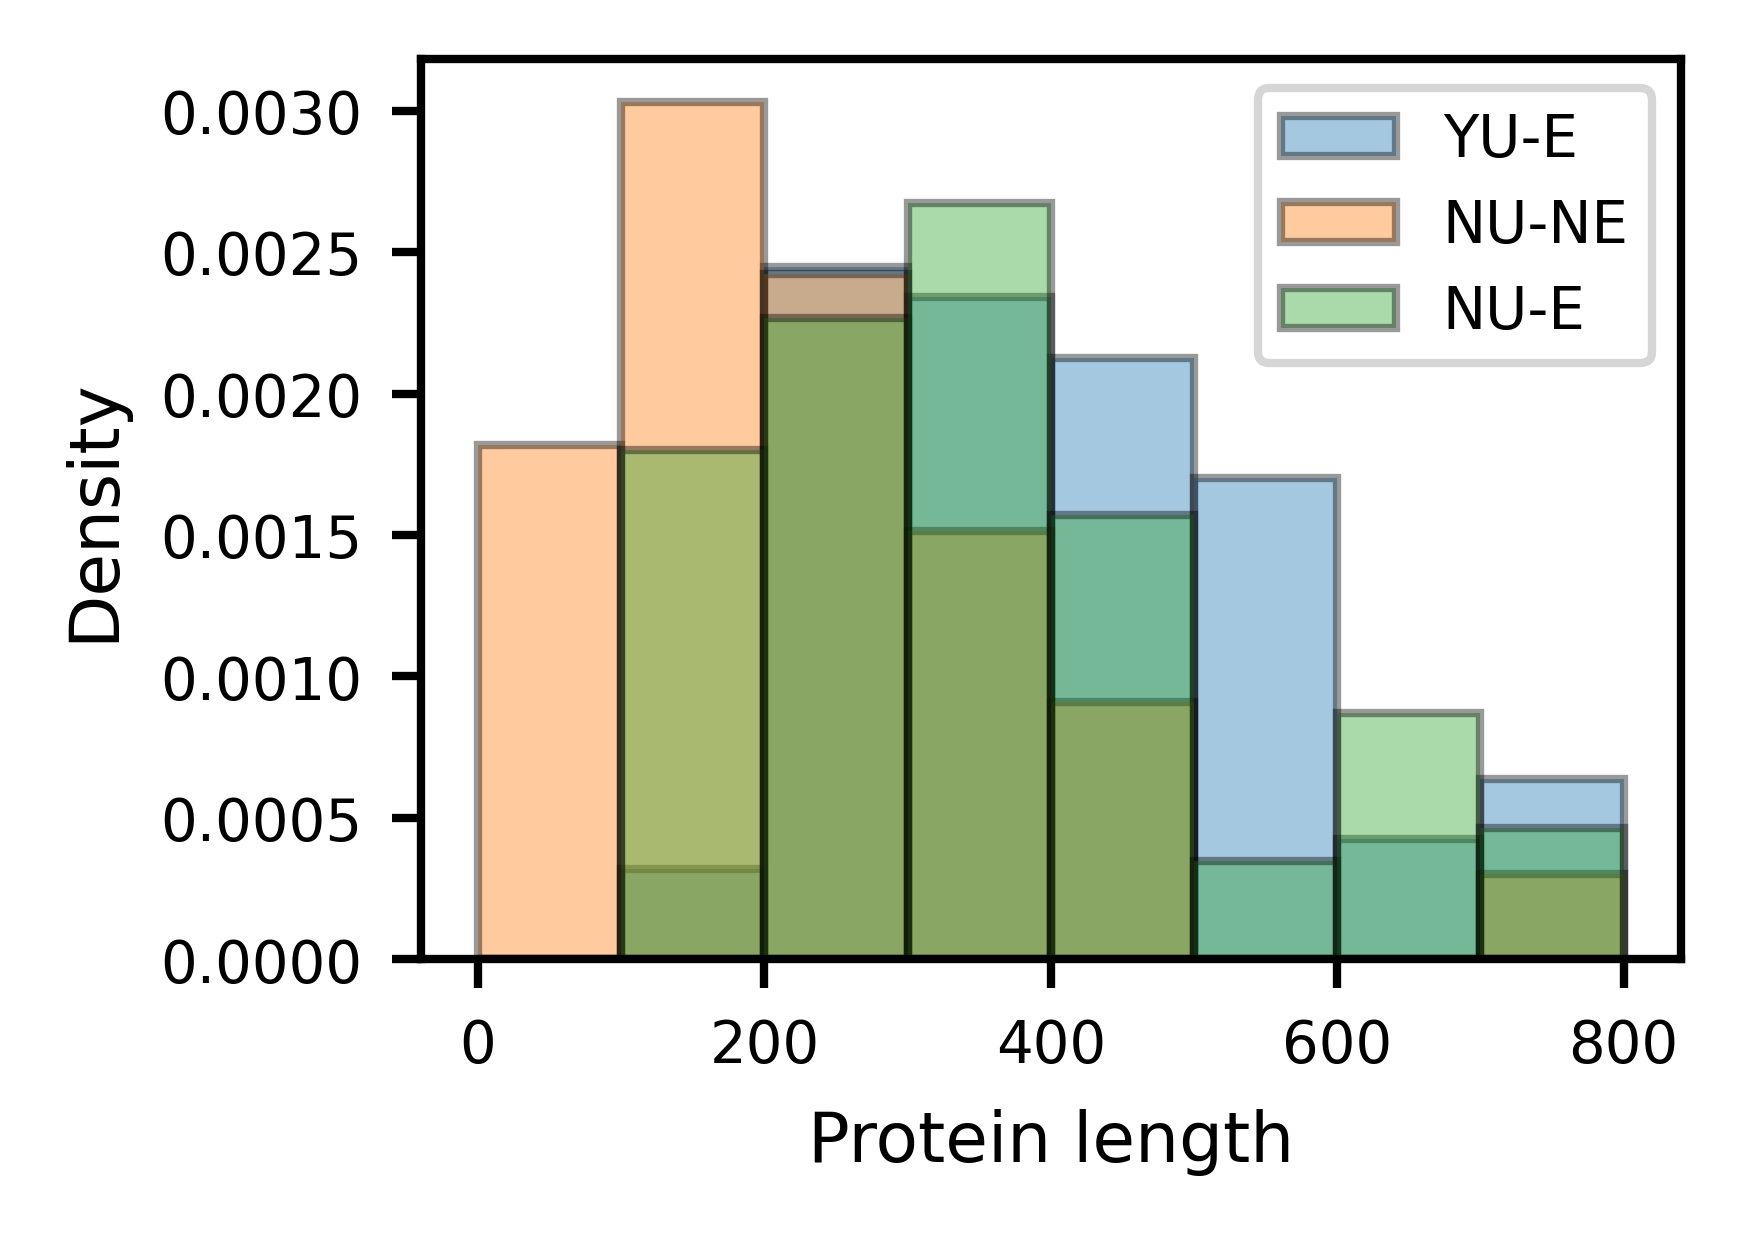

In [11]:
AF_shape_df = pd.read_excel('AF_Human_shape.xlsx')

# In AF dataset
AF_YU_E_len_df = df_dict['YU-E']
AF_YU_E_len_df = AF_YU_E_len_df.merge(AF_shape_df, on='Uniprot', how='left')

AF_NU_NE_len_df = df_dict['NU-NE']
AF_NU_NE_len_df = AF_NU_NE_len_df.merge(AF_shape_df, on='Uniprot', how='left')

AF_NU_E_len_df = df_dict['NU-E']
AF_NU_E_len_df = AF_NU_E_len_df.merge(AF_shape_df, on='Uniprot', how='left')

Asphericity_cutoff = 0.1
num_protein = 10
length_buffer = 10

AF_YU_E_len_df = AF_YU_E_len_df.loc[AF_YU_E_len_df['Asphericity'] <= Asphericity_cutoff]
AF_NU_NE_len_df = AF_NU_NE_len_df.loc[AF_NU_NE_len_df['Asphericity'] <= Asphericity_cutoff]
AF_NU_E_len_df = AF_NU_E_len_df.loc[AF_NU_E_len_df['Asphericity'] <= Asphericity_cutoff]
print('After shape control, number of proteins drop to %d, %d and %d'%(AF_YU_E_len_df.shape[0], 
                                                                       AF_NU_NE_len_df.shape[0],
                                                                       AF_NU_E_len_df.shape[0]))

# Plot distribution
fig = plt.figure(figsize=(3,2))
plt.subplots_adjust(top=0.95, bottom=0.20, left=0.20, hspace=0.30)
ax = fig.add_subplot(1,1,1)
edges = np.linspace(0, 800, 9)
ax.hist(AF_YU_E_len_df['Length'], bins=edges, histtype='bar', density=True, edgecolor='black', alpha=0.4, label='YU-E')
ax.hist(AF_NU_NE_len_df['Length'], bins=edges, histtype='bar', density=True, edgecolor='black', alpha=0.4, label='NU-NE')
ax.hist(AF_NU_E_len_df['Length'], bins=edges, histtype='bar', density=True, edgecolor='black', alpha=0.4, label='NU-E')
ax.set_xlabel('Protein length')
ax.set_ylabel('Density')
ax.legend()
plt.show()

In [12]:
def select_YU_E_proteins(random_seed):
    selected_AF_YU_E_df = AF_YU_E_len_df[column_sel].sample(num_protein)
    return selected_AF_YU_E_df

def select_NU_NE_proteins(random_seed):
    # Matching the protein lengths in selected YU-E proteins
    rm_uid_list = ['P51888', 'Q96IG2'] # Example 2 proteins with elongated shape after visual inspection
    df_2 = AF_NU_NE_len_df[column_sel].copy()
    selected_AF_NU_NE_df = pd.DataFrame(columns=column_sel)
    for index, row in selected_AF_YU_E_df.iterrows():
        prot_length = row['Length']
        i = 1
        tag_break = False
        while not tag_break:
            sub_df = df_2.loc[(df_2['Length']>=prot_length-length_buffer*i) 
                              & (df_2['Length']<=prot_length+length_buffer*i)]
            if not sub_df.empty:
                sel = sub_df.sample(1, random_state=random_seed)
                if sel['Uniprot'].values[0] in rm_uid_list:
                    sub_df = sub_df.drop(sub_df[sub_df['Uniprot']==sel['Uniprot'].values[0]].index)
                    while not sub_df.empty:
                        sel = sub_df.sample(1, random_state=random_seed)
                        if sel['Uniprot'].values[0] not in rm_uid_list:
                            selected_AF_NU_NE_df = pd.concat([selected_AF_NU_NE_df, sel], join='outer')
                            df_2 = df_2.drop(sel.index)
                            tag_break = True
                            break
                        sub_df = sub_df.drop(sub_df[sub_df['Uniprot']==sel['Uniprot'].values[0]].index)
                else:
                    selected_AF_NU_NE_df = pd.concat([selected_AF_NU_NE_df, sel], join='outer')
                    df_2 = df_2.drop(sel.index)
                    tag_break = True
            i += 1
    return selected_AF_NU_NE_df

def select_NU_E_proteins(random_seed):
    # Matching the protein lengths in selected YU-E proteins
    rm_uid_list = []
    df_3 = AF_NU_E_len_df[column_sel].copy()
    selected_AF_NU_E_df = pd.DataFrame(columns=column_sel)
    for index, row in selected_AF_YU_E_df.iterrows():
        prot_length = row['Length']
        i = 1
        tag_break = False
        while not tag_break:
            sub_df = df_3.loc[(df_3['Length']>=prot_length-length_buffer*i) 
                              & (df_3['Length']<=prot_length+length_buffer*i)]
            if not sub_df.empty:
                sel = sub_df.sample(1, random_state=random_seed)
                if sel['Uniprot'].values[0] in rm_uid_list:
                    sub_df = sub_df.drop(sub_df[sub_df['Uniprot']==sel['Uniprot'].values[0]].index)
                    while not sub_df.empty:
                        sel = sub_df.sample(1, random_state=random_seed)
                        if sel['Uniprot'].values[0] not in rm_uid_list:
                            selected_AF_NU_E_df = pd.concat([selected_AF_NU_E_df, sel], join='outer')
                            df_3 = df_3.drop(sel.index)
                            tag_break = True
                            break
                        sub_df = sub_df.drop(sub_df[sub_df['Uniprot']==sel['Uniprot'].values[0]].index)
                else:
                    selected_AF_NU_E_df = pd.concat([selected_AF_NU_E_df, sel], join='outer')
                    df_3 = df_3.drop(sel.index)
                    tag_break = True
            i += 1
    return selected_AF_NU_E_df


random_seed = 1 # change the random seed if needed
column_sel = ['Uniprot', 'Name', 'Length', 'Asphericity']

selected_AF_YU_E_df = select_YU_E_proteins(random_seed)
display(selected_AF_YU_E_df)

selected_AF_NU_NE_df = select_NU_NE_proteins(random_seed)
display(selected_AF_NU_NE_df)

selected_AF_NU_E_df = select_NU_E_proteins(random_seed)
display(selected_AF_NU_E_df)

,Uniprot,Name,Length,Asphericity
171,Q9Y2Q3,Glutathione S-transferase kappa 1,226,0.03
70,O00743,Serine/threonine-protein phosphatase 6 catalyt...,305,0.06
65,P17812,CTP synthase 1,591,0.10
54,Q13547,Histone deacetylase 1,482,0.09
71,P17174,"Aspartate aminotransferase, cytoplasmic",413,0.05
247,P37837,Transaldolase,337,0.08
233,P49419,Alpha-aminoadipic semialdehyde dehydrogenase,539,0.10
113,P00491,Purine nucleoside phosphorylase,289,0.06
67,P04181,"Ornithine aminotransferase, mitochondrial",439,0.03
225,Q8WU76,Sec1 family domain-containing protein 2,684,0.03


,Uniprot,Name,Length,Asphericity
28,P09488,Glutathione S-transferase Mu 1,218,0.08
139,Q9BU89,Deoxyhypusine hydroxylase,302,0.05
20,P02774,Vitamin D-binding protein,474,0.08
110,Q8IV38,Ankyrin repeat and MYND domain-containing prot...,441,0.04
97,Q6NVY1,"3-hydroxyisobutyryl-CoA hydrolase, mitochondrial",386,0.10
33,P16520,Guanine nucleotide-binding protein G(I)/G(S)/G...,340,0.09
81,Q12996,Cleavage stimulation factor subunit 3,717,0.09
0,A6NDU8,RAB7A-interacting MON1-CCZ1 complex subunit 1,294,0.09
84,Q13825,"Methylglutaconyl-CoA hydratase, mitochondrial",339,0.10
120,Q8WV22,Non-structural maintenance of chromosomes elem...,266,0.02


,Uniprot,Name,Length,Asphericity
86,P22061,Protein-L-isoaspartate(D-aspartate) O-methyltr...,227,0.01
222,Q16836,"Hydroxyacyl-coenzyme A dehydrogenase, mitochon...",314,0.10
289,Q8NHQ9,ATP-dependent RNA helicase DDX55,600,0.10
105,P34896,"Serine hydroxymethyltransferase, cytosolic",483,0.07
214,Q15120,[Pyruvate dehydrogenase (acetyl-transferring)]...,406,0.10
52,P06746,DNA polymerase beta,335,0.07
258,Q7L1T6,Cytochrome b5 reductase 4,521,0.08
454,Q9Y316,Protein MEMO1,297,0.06
448,Q9Y2G5,GDP-fucose protein O-fucosyltransferase 2,429,0.09
378,Q9H6R3,Acyl-CoA synthetase short-chain family member ...,686,0.03
